# Experiment 08 — Directional (Physics-Motivated) Motion Blur Detection
**Purpose.**  Replace the isotropic Gaussian blur of v1-v3 with a
physically motivated directional motion PSF, as required by both
review panels (Meta-Rad R1 #1, RYAI R1/R2).
Physics:
  * Cranio-caudal linear blur  (angle=90 deg)  -> diaphragmatic motion
  * Lateral (left-right) blur  (angle= 0 deg)  -> cardiac wall motion
For each direction and a standard set of exposure-equivalent kernel
lengths (11, 21, 31 px) and patch footprints (16, 32, 64 px) we extract
CLS embeddings and run a linear detection probe for each model.
**How to run.**
    export DATASET=nih
    jupyter nbconvert --execute --to notebook 08_DirectionalMotionBlur.ipynb
Output: `exp08_<dataset>_directional_blur.parquet` + visualisations.

In [1]:
import os, sys, gc, json
from pathlib import Path
REPO_ROOT = Path(os.environ.get("REPO_ROOT", "/home/saptpurk/embeddings-noise-eliminators/v4"))
sys.path.insert(0, str(REPO_ROOT))

from common import (
    get_config, PARAMS, MODELS, HF_TOKEN, models_to_run,
    DirectionalMotionBlurInjector, EmbeddingExtractor,
    train_probe, load_disease_labels, load_and_pad, stratified_split,
)

CFG = get_config()
OUT = CFG.output_dir("exp08_directional_blur")
print(f"Dataset: {CFG.name}  |  Output: {OUT}")

Dataset: NIH-CXR14  |  Output: /home/saptpurk/embeddings-noise-eliminators/v4_work/v4_exp08_directional_blur_nih


In [2]:
import numpy as np, pandas as pd, torch
from tqdm.auto import tqdm

SEED = PARAMS.random_seed
MODEL_NAMES = models_to_run()
print(f"Running models: {MODEL_NAMES}")

# Full parameter grid
ANGLES         = [("cranio_caudal", 90.0), ("lateral", 0.0)]
KERNEL_LENGTHS = [11, 21, 31]
PATCH_SIZES    = [16, 32, 64]

Running models: ['raddino', 'dinov2', 'biomedclip']


In [3]:
df_all = load_disease_labels(CFG, ["cardiomegaly"])
rng = np.random.default_rng(SEED)
n_target = min(40_000, len(df_all))
idx = rng.choice(len(df_all), size=n_target, replace=False)
df = df_all.iloc[idx].reset_index(drop=True)
df["_stratum"] = "0"
train_df, test_df = stratified_split(df, "_stratum", test_frac=0.2, seed=SEED)
print(f"train={len(train_df)}  test={len(test_df)}")

train=32000  test=8000


In [4]:
def extract_dirblur(extractor, df, angle_deg, klen, patch_size, split_tag):
    cache = OUT / f"emb_{extractor.model_name}_{split_tag}_{angle_deg:.0f}_k{klen}_p{patch_size}.npz"
    if cache.exists():
        npz = np.load(cache)
        return npz["clean"], npz["pert"]

    injector = DirectionalMotionBlurInjector(
        seed=SEED, kernel_length=klen, angle_deg=angle_deg,
    )
    from common import parallel_iter
    clean_emb, pert_emb = [], []
    n_batches = (len(df) + PARAMS.batch_size - 1) // PARAMS.batch_size
    pbar = tqdm(parallel_iter(df["image_path"].tolist(), CFG.target_size,
                              batch_size=PARAMS.batch_size,
                              num_workers=PARAMS.num_workers,
                              injector=injector, patch_size=patch_size),
                total=n_batches,
                desc=f"{extractor.model_name}/{split_tag}/"
                     f"a={angle_deg:.0f}/k={klen}/p={patch_size}")
    for clean_imgs, pert_imgs, _ in pbar:
        clean_emb.append(extractor.extract_cls(clean_imgs))
        pert_emb.append(extractor.extract_cls(pert_imgs))

    clean_emb = np.vstack(clean_emb)
    pert_emb  = np.vstack(pert_emb)
    np.savez_compressed(cache, clean=clean_emb, pert=pert_emb)
    return clean_emb, pert_emb


def probe(clean_tr, pert_tr, clean_te, pert_te, tag):
    Xtr = np.vstack([clean_tr, pert_tr])
    ytr = np.concatenate([np.zeros(len(clean_tr)), np.ones(len(pert_tr))]).astype(int)
    Xte = np.vstack([clean_te, pert_te])
    yte = np.concatenate([np.zeros(len(clean_te)), np.ones(len(pert_te))]).astype(int)
    res, _ = train_probe(
        Xtr, ytr, Xte, yte,
        name=tag,
        C_grid=PARAMS.lr_C_grid,
        n_boot=PARAMS.n_bootstrap,
        max_iter=PARAMS.lr_max_iter,
        seed=SEED, verbose=False,
    )
    return res

In [5]:
records = []
for model_name in MODEL_NAMES:
    print(f"\n=== {model_name.upper()} ===")
    ext = EmbeddingExtractor(
        model_name,
        hf_token=HF_TOKEN if MODELS[model_name]["requires_token"] else None,
    )
    for angle_name, angle_deg in ANGLES:
        for klen in KERNEL_LENGTHS:
            for ps in PATCH_SIZES:
                c_tr, p_tr = extract_dirblur(ext, train_df, angle_deg, klen, ps, "train")
                c_te, p_te = extract_dirblur(ext, test_df,  angle_deg, klen, ps, "test")
                tag = f"{model_name}/{angle_name}/k{klen}/p{ps}"
                res = probe(c_tr, p_tr, c_te, p_te, tag)
                records.append(dict(
                    dataset=CFG.dataset, model=model_name,
                    direction=angle_name, angle_deg=angle_deg,
                    kernel_length=klen, patch_size=ps,
                    auc=res.auc,
                    auc_ci_low=res.auc_ci[0], auc_ci_high=res.auc_ci[1],
                    f1=res.f1, threshold=res.threshold, best_C=res.best_C,
                    n_train=res.n_train, n_test=res.n_test,
                ))
                print(f"  {tag}  AUC={res.auc:.4f} "
                      f"[{res.auc_ci[0]:.4f}, {res.auc_ci[1]:.4f}]")
    ext.close()
    del ext; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


=== RADDINO ===


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

raddino/train/a=90/k=11/p=16:   0%|          | 0/2000 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


raddino/test/a=90/k=11/p=16:   0%|          | 0/500 [00:00<?, ?it/s]

...

  biomedclip/lateral/k31/p32  AUC=0.5059 [0.4972, 0.5141]


biomedclip/train/a=0/k=31/p=64:   0%|          | 0/2000 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


biomedclip/test/a=0/k=31/p=64:   0%|          | 0/500 [00:00<?, ?it/s]

  biomedclip/lateral/k31/p64  AUC=0.5339 [0.5253, 0.5423]


In [6]:
df_out = pd.DataFrame(records)
_run_tag = os.environ.get("RUN_TAG", "")
_suffix = ("_" + _run_tag) if _run_tag else ""
out_path = OUT / f"exp08_{CFG.dataset}_directional_blur{_suffix}.parquet"
df_out.to_parquet(out_path, index=False)
print(f"\nSaved -> {out_path}")


Saved -> /home/saptpurk/embeddings-noise-eliminators/v4_work/v4_exp08_directional_blur_nih/exp08_nih_directional_blur_gpu0.parquet


## Quick summary heatmap

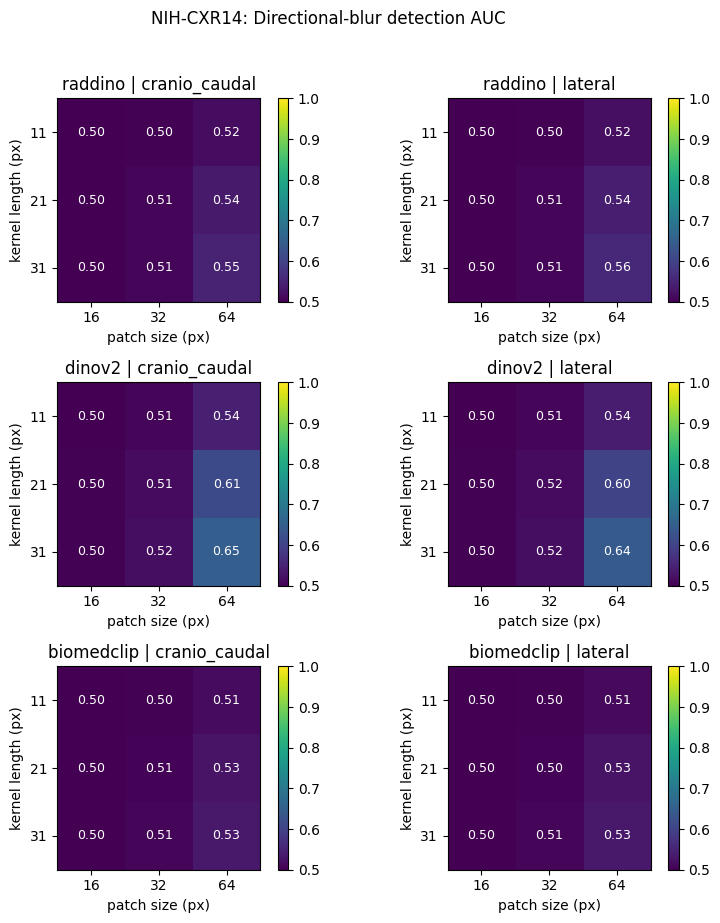

In [7]:
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(len(MODEL_NAMES), len(ANGLES),
                             figsize=(4 * len(ANGLES), 3 * len(MODEL_NAMES)),
                             squeeze=False)
    for i, model_name in enumerate(MODEL_NAMES):
        for j, (aname, _) in enumerate(ANGLES):
            sub = df_out[(df_out["model"] == model_name) &
                         (df_out["direction"] == aname)]
            pivot = sub.pivot(index="kernel_length", columns="patch_size",
                              values="auc")
            ax = axes[i, j]
            im = ax.imshow(pivot.values, cmap="viridis", vmin=0.5, vmax=1.0)
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels(pivot.columns)
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels(pivot.index)
            ax.set_title(f"{model_name} | {aname}")
            ax.set_xlabel("patch size (px)"); ax.set_ylabel("kernel length (px)")
            for (r, c), v in np.ndenumerate(pivot.values):
                ax.text(c, r, f"{v:.2f}", ha="center", va="center",
                        color="white" if v < 0.75 else "black", fontsize=9)
            plt.colorbar(im, ax=ax, fraction=0.046)
    plt.suptitle(f"{CFG.name}: Directional-blur detection AUC", y=1.02)
    plt.tight_layout()
    plt.savefig(OUT / "directional_blur_summary.png", dpi=200, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"Plot skipped: {e}")